In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import requests
from io import BytesIO
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 10000 files belonging to 10 classes.


In [3]:
val_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 1000 files belonging to 10 classes.


In [4]:
conv_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3), pooling='avg')
conv_base.trainable = False

In [5]:
def extract_features(data):
    features = []
    labels = []
    for images, label in data:
        try :
            feature_batch = conv_base.predict(images)
            features.append(feature_batch)
            labels.append(label)
        except Exception as e:
            print(f"Error occurred while processing {images.file_path}: {e}")
            continue
    return np.vstack(features), np.vstack(labels)

In [6]:
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [7]:
print("Sample train features (first 5 rows):", train_features[:5])
print("Sample train labels (first 5):", train_labels[:5])
print("Sample validation features (first 5 rows):", val_features[:5])
print("Sample validation labels (first 5):", val_labels[:5])

Sample train features (first 5 rows): [[4.4567775e-04 2.7449534e-03 3.2968381e-03 ... 2.4469314e+00
  8.4397906e-01 1.9795606e+00]
 [3.3331732e-04 4.0721544e-03 5.5980524e-03 ... 2.0227649e+00
  3.0931348e-01 8.4778857e-01]
 [3.6798709e-04 3.9183977e-03 3.2234860e-03 ... 3.2127357e+00
  3.6200780e-01 1.5113724e+00]
 [4.0506513e-04 6.0320091e-03 2.6240265e-03 ... 3.0018518e+00
  3.4253708e-01 6.1296028e-01]
 [4.1119353e-04 7.8654047e-03 2.6264850e-03 ... 2.8962476e+00
  3.0235879e-02 8.4135389e-01]]
Sample train labels (first 5): [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
Sample validation features (first 5 rows): [[4.2215976e-04 3.5674176e-03 3.9157816e-03 ... 3.1032460e+00
  6.5036249e-01 1.9185574e+00]
 [5.3229759e-04 6.9138594e-03 4.6486012e-03 ... 3.3871305e+00
  3.0118740e-01 1.2579122e+00]
 [4.7502661e-04 5.6751999e-03 3.7820227e-03 ... 1.2491015e+00
  1.8903

# Flatten labels for compatibility


In [8]:
train_labels = np.argmax(train_labels, axis=1)
val_labels = np.argmax(val_labels, axis=1)

In [9]:
print(train_data)
print(val_data)

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>


# Train Random Forest Classifier


In [10]:
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(train_features, train_labels)

RandomForestClassifier(n_estimators=200, random_state=42)

In [11]:
rf_predictions = rf_classifier.predict(val_features)
random_forest_accuracy = accuracy_score(val_labels, rf_predictions)  * 100
print("Random Forest Accuracy:", accuracy_score(val_labels, rf_predictions) * 100)
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(val_labels, rf_predictions))

Random Forest Accuracy: 89.1
Confusion Matrix (Random Forest):
[[ 98   0   0   0   0   0   0   2   0   0]
 [  3  83   4   2   4   1   2   0   1   0]
 [  0   7  88   1   2   0   2   0   0   0]
 [  0   2   0  84   0   0   8   1   5   0]
 [  3   6   3   2  83   0   3   0   0   0]
 [  0   1   0   5   0  86   6   0   1   1]
 [  1   2   0   2   2  10  81   0   0   2]
 [  3   0   0   0   1   0   0  96   0   0]
 [  0   0   0   0   0   0   0   0 100   0]
 [  0   0   0   0   0   0   7   0   1  92]]


# Simple CNN

In [12]:
def create_simple_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

## Training the model with 5 epoch

In [13]:
simple_cnn = create_simple_cnn()
simple_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
simple_cnn.fit(train_data, epochs=5, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

c:\Program Files\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 266s 837ms/step - accuracy: 0.5583 - loss: 1.9840 - val_accuracy: 0.2000 - val_loss: 5.6093
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 853ms/step - accuracy: 0.8093 - loss: 0.6335 - val_accuracy: 0.6930 - val_loss: 1.1210
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 273s 872ms/step - accuracy: 0.8598 - loss: 0.4324 - val_accuracy: 0.8020 - val_loss: 0.8310
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 282s 899ms/step - accuracy: 0.8980 - loss: 0.3306 - val_accuracy: 0.8780 - val_loss: 0.4397
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 213s 679ms/step - accuracy: 0.9220 - loss: 0.2423 - val_accuracy: 0.8760 - val_loss: 0.5343


In [14]:
simple_cnn_eval = simple_cnn.evaluate(val_data)
simple_cnn_accuracy = simple_cnn_eval[1] * 100
print("Simple CNN Accuracy:", simple_cnn_eval[1] * 100)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.8685 - loss: 0.5979
Simple CNN Accuracy: 87.59999871253967


In [15]:
def create_densenet_cnn():
    model = Sequential([
        conv_base,
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dropout(0.35),
        BatchNormalization(),
        Dense(120, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [16]:
densenet_cnn = create_densenet_cnn()
densenet_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
densenet_cnn.fit(train_data, epochs=17, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.3260 - loss: 1.9776 - val_accuracy: 0.7630 - val_loss: 0.9067
Epoch 2/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.7594 - loss: 0.7625 - val_accuracy: 0.8510 - val_loss: 0.5171
Epoch 3/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.8289 - loss: 0.5239 - val_accuracy: 0.8790 - val_loss: 0.3891
Epoch 4/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.8691 - loss: 0.4052 - val_accuracy: 0.8880 - val_loss: 0.3328
Epoch 5/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.8953 - loss: 0.3229 - val_accuracy: 0.9010 - val_loss: 0.2864
Epoch 6/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.9042 - loss: 0.2827 - val_accuracy: 0.9100 - val_loss: 0.2542
Epoch 7/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.9280 - loss: 0.2325 - val_accuracy: 0.9210 - val_loss: 0.2325
Epoch 8/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.9323 - loss: 0.2068 - val_accu

In [17]:
densenet_cnn_eval = densenet_cnn.evaluate(val_data)
print("DenseNet CNN Accuracy:", densenet_cnn_eval[1] * 100)
densenet_cnn_accuracy = densenet_cnn_eval[1] * 100

32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9573 - loss: 0.1404
DenseNet CNN Accuracy: 95.39999961853027


In [18]:
def predict_from_url(url, model, model_type='densenet'):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).resize((256, 256))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    if model_type == 'rf':
        features = conv_base.predict(img_array)
        prediction = model.predict(features)
        predicted_label = np.argmax(prediction)
    elif model_type == 'simple_cnn':
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)
    elif model_type == 'densenet':
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)

    return predicted_label

In [19]:
class_labels = [
    "Bacterial Spot", 
    "Early Blight",   
    "Healthy",   
    "Late Blight",
    "Leaf Mold",
    "Septoria leaf spot",
    "Two Spotted Spider mite",
    "Target spot",
    "mosaic virus",
    "yellow leaf virus"
]

In [20]:
example_url = "https://imgs.search.brave.com/uz3gL-xyiTp9T-ffOfowK0tgQKpmUfNZeB9aiXebHYY/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9wbGFu/dGNhcmV0b2RheS5j/b20vd3AtY29udGVu/dC91cGxvYWRzL3Rv/bWF0by15ZWxsb3ct/bGVhdmVzLTEyMDAt/NjMwLUZCLTAzMzEy/MDE5LW1pbi5qcGc"
predicted_rf_disease = predict_from_url(example_url, rf_classifier, model_type='rf')
predicted_simple_cnn_disease = predict_from_url(example_url, simple_cnn, model_type='simple_cnn')
predicted_densenet_disease = predict_from_url(example_url, densenet_cnn, model_type='densenet')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [21]:
predicted_rf_disease_name = class_labels[predicted_rf_disease]
predicted_simple_cnn_disease_name = class_labels[predicted_simple_cnn_disease]
predicted_densenet_disease_name = class_labels[predicted_densenet_disease]

In [22]:
print("Predicted Disease Label (Random Forest):", predicted_rf_disease_name)
print("Predicted Disease Label (Simple CNN):", predicted_simple_cnn_disease_name)
print("Predicted Disease Label (DenseNet CNN):", predicted_densenet_disease_name)

Predicted Disease Label (Random Forest): Bacterial Spot
Predicted Disease Label (Simple CNN): Early Blight
Predicted Disease Label (DenseNet CNN): Healthy


C:\Users\tiger\AppData\Local\Temp\ipykernel_26292\3238778116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')


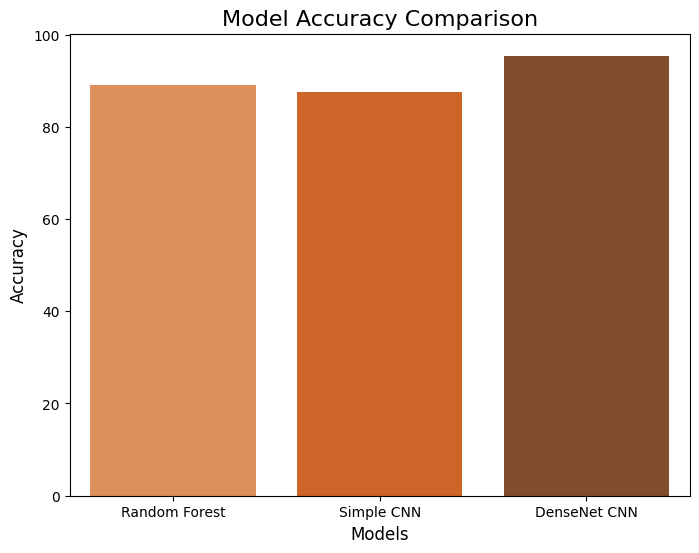

In [23]:
model_names = ['Random Forest', 'Simple CNN', 'DenseNet CNN']
accuracies = [random_forest_accuracy, simple_cnn_accuracy, densenet_cnn_accuracy]  # Replace with actual accuracy values

# Create a bar plot for model accuracies
plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Show the plot
plt.show()

In [24]:
densenet_predictions = np.argmax(densenet_cnn.predict(val_data), axis=1)
simple_cnn_predictions = np.argmax(simple_cnn.predict(val_data), axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step


In [25]:
densenet_cm = confusion_matrix(val_labels, densenet_predictions)
print(densenet_cm)

[[11 11 13  7  6 12  6 13 13  8]
 [ 7 11 11 12  6 11  7 16  8 11]
 [15  9 13  6  9  9  7 11 13  8]
 [17 10 10 12 11  7 12  7  9  5]
 [ 8 11  8 12 11  7 11  6 10 16]
 [ 6 10 10 12 10 13 13  6  9 11]
 [11 14  8 13  9 11  9  6  9 10]
 [ 9 10  7  5 11 14 13 13  9  9]
 [ 8  5  9  9 13 10 10 10 12 14]
 [ 9  9 15  7 11  9  9 11 13  7]]


In [26]:
simple_cnn_cm = confusion_matrix(val_labels, simple_cnn_predictions)
print(simple_cnn_cm)

[[10 13  7  6  6 16  8 10 15  9]
 [12  6 10  5 13 10 12 11 10 11]
 [11  9  5  7 13  6  7 13 17 12]
 [10 12  9  6 15  7 11 14  9  7]
 [14  6 11  8  7  5 13 12 13 11]
 [ 8 13 11 11 10  4 11 13 10  9]
 [ 9 13  9  7 11 16 10  3 10 12]
 [15 13  8  4 12  9  9  6 13 11]
 [ 4  9 13  8 15 10 11  9 13  8]
 [ 6  8  7 12 22  7 11 11 10  6]]


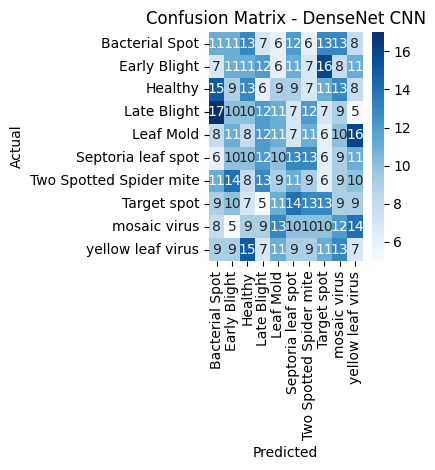

In [27]:
plt.subplot(1, 2, 1)
sns.heatmap(densenet_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DenseNet CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

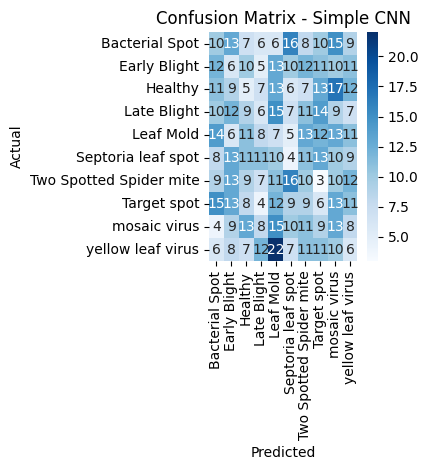

In [28]:
plt.subplot(1, 2, 2)
sns.heatmap(simple_cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Simple CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [29]:
densenet_cnn.save("densenet_tomato_model.h5")